In [23]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path(r"C:\Users\kelvi\Downloads\returns_daily_wide (1).csv")

def load_returns_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)

    # Drop a dumped index column if present
    for junk in ["Unnamed: 0", "0"]:
        if junk in df.columns and pd.api.types.is_integer_dtype(df[junk]):
            df = df.drop(columns=[junk])

    # Find the date column (expect 'date' per your file)
    date_col = next((c for c in df.columns if str(c).strip().lower() in {"date","dates"}), None)
    if date_col is None:
        raise ValueError(f"No date column found in {path.name}. Columns: {list(df.columns)}")

    # Rename to 'date' first, then parse (so we don't drop it by accident)
    if date_col != "date":
        df = df.rename(columns={date_col: "date"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Keep, sort, index by date
    df = df.dropna(subset=["date"]).sort_values("date").set_index("date")

    # Drop cumulative columns if present
    keep_cols = [c for c in df.columns if not str(c).endswith("_cum")]
    df = df[keep_cols].copy()

    # Force numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Ensure LS exists
    if "LS" not in df.columns and {"Q1","Q5"}.issubset(df.columns):
        df["LS"] = df["Q1"] - df["Q5"]

    # Nice order if available
    ordered = [c for c in ["Q1","Q2","Q3","Q4","Q5","LS","LO"] if c in df.columns]
    if ordered:
        df = df[ordered]

    return df

# Use it
dw = load_returns_csv(CSV_PATH)
print("Columns:", list(dw.columns))
print("Range:", dw.index.min().date(), "→", dw.index.max().date(), "| rows:", len(dw))
display(dw.head())


Columns: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'LS', 'LO']
Range: 1988-03-01 → 2024-12-31 | rows: 8894


,Q1,Q2,Q3,Q4,Q5,LS,LO
date,,,,,,,
1988-03-01,0.001244,0.001244,0.001244,0.001244,0.001244,0.0,0.000837
1988-03-02,0.004034,0.004034,0.004034,0.004034,0.004034,0.0,0.004502
1988-03-03,0.001252,0.001252,0.001252,0.001252,0.001252,0.0,0.002223
1988-03-04,-0.002348,-0.002348,-0.002348,-0.002348,-0.002348,0.0,-0.000426
1988-03-07,-0.000966,-0.000966,-0.000966,-0.000966,-0.000966,0.0,0.000611


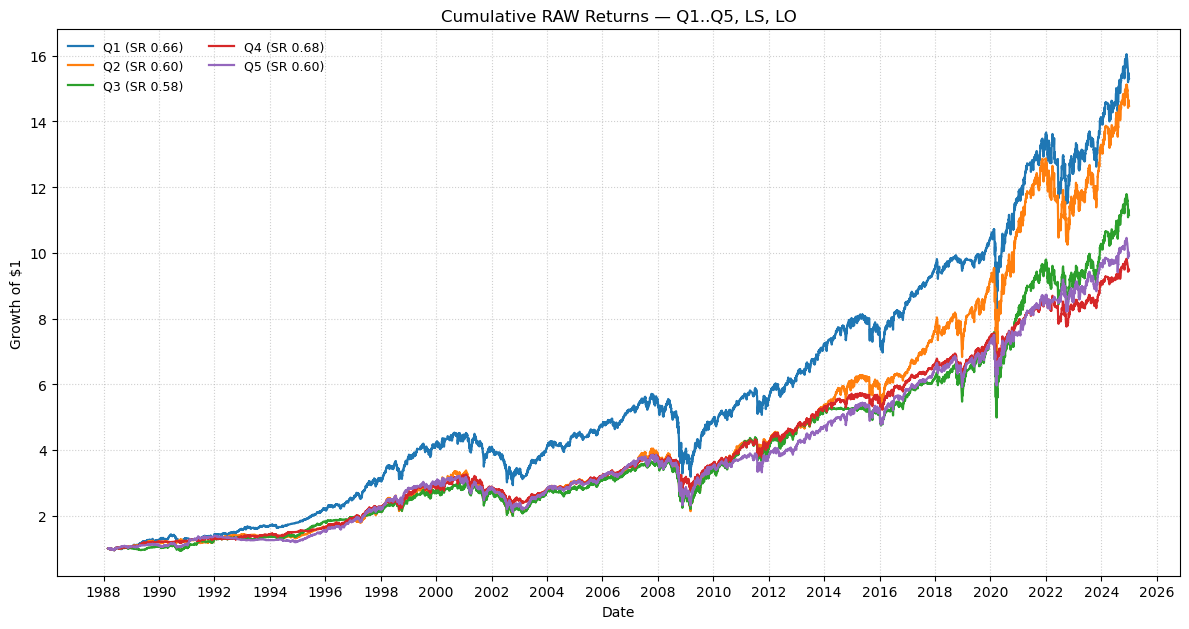

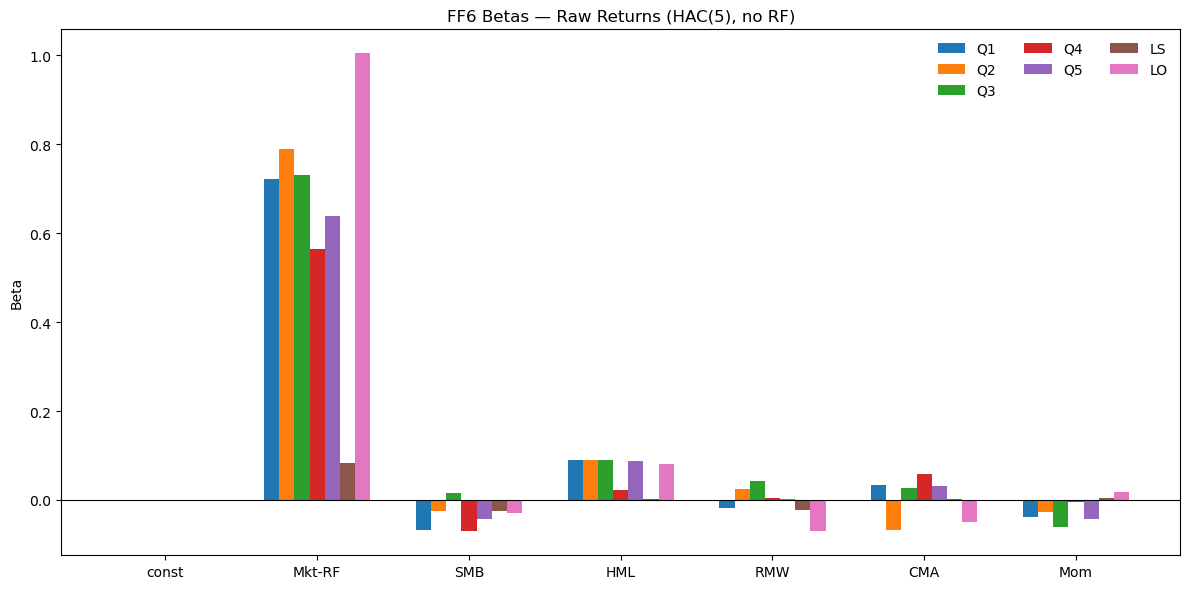

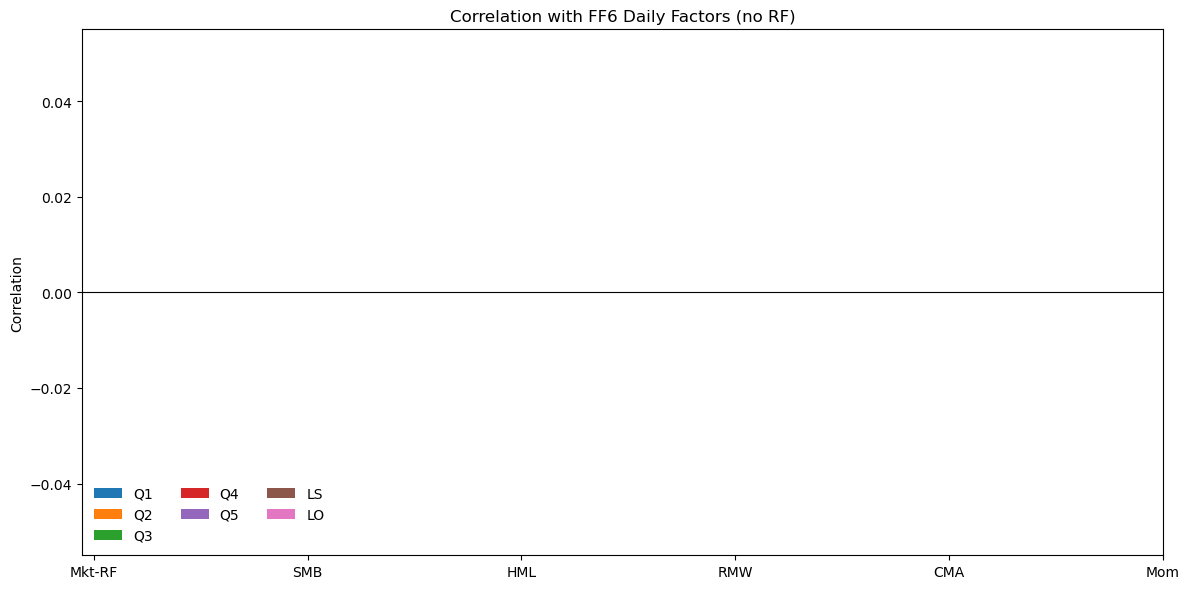


=== FF6 betas (no RF regressor) — daily raw returns ===


,const,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,0.0001,0.7211,-0.0686,0.0898,-0.0191,0.0328,-0.0377
Q2,0.0000,0.7900,-0.0252,0.0906,0.0235,-0.0669,-0.0278
Q3,0.0000,0.7316,0.0148,0.0892,0.0429,0.0261,-0.0613
Q4,0.0000,0.5639,-0.0696,0.0228,0.0040,0.0581,-0.0057
Q5,0.0001,0.6385,-0.0436,0.0883,0.0029,0.0315,-0.0422
LS,0.0000,0.0826,-0.0250,0.0015,-0.0220,0.0013,0.0046
LO,0.0001,1.0050,-0.0302,0.0810,-0.0707,-0.0497,0.0186



=== FF6 t-stats (no RF regressor) ===


,const,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,2.67,90.90,-11.13,12.21,-1.67,3.31,-9.20
Q2,1.05,91.81,-2.86,10.13,2.10,-5.23,-4.93
Q3,1.53,53.36,1.41,8.28,3.07,2.06,-8.56
Q4,1.90,74.52,-8.31,2.03,0.31,4.67,-0.96
Q5,1.56,42.43,-4.11,6.38,0.16,1.88,-4.96
LS,0.33,7.05,-2.25,0.12,-1.26,0.08,0.53
LO,7.47,185.91,-4.56,10.62,-5.40,-5.16,3.10



=== Correlations with FF6 daily factors (no RF) ===


,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,NaN,NaN,NaN,NaN,NaN,NaN
Q2,NaN,NaN,NaN,NaN,NaN,NaN
Q3,NaN,NaN,NaN,NaN,NaN,NaN
Q4,NaN,NaN,NaN,NaN,NaN,NaN
Q5,NaN,NaN,NaN,NaN,NaN,NaN
LS,NaN,NaN,NaN,NaN,NaN,NaN
LO,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ============================================================
# Parquet + FF6 (no RF in regressors) — NO MSCI EXCESS SECTION
# - Regressions & correlations on RAW returns (no RF regressor)
# - Plot ONLY cumulative raw quantile/LS/LO if you want (optional)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from pathlib import Path

# ---------- PATHS ----------
PARQUET_PATH = Path(r"C:\Users\kelvi\Downloads\returns_daily_wide.parquet")
FF6_XLSX     = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"
FF6_CSV      = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.csv"

# ---------- LOADERS ----------
def load_daily_wide_parquet(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("Parquet must have a 'date' column or a DatetimeIndex.")
        df = df.sort_index()
    for c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    keep = [c for c in df.columns if not str(c).endswith("_cum")]
    df = df[keep]
    if "LS" not in df and {"Q1","Q5"}.issubset(df.columns):
        df["LS"] = df["Q1"] - df["Q5"]
    return df

def read_ff6_pandas(xlsx_path: str | None, csv_path: str | None) -> pd.DataFrame:
    if xlsx_path and Path(xlsx_path).exists():
        ff = pd.read_excel(xlsx_path)
    elif csv_path and Path(csv_path).exists():
        ff = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("Provide a valid FF6 Excel or CSV path.")
    ren = {"Mkt_RF":"Mkt-RF", "MKTRF":"Mkt-RF", "RmMinusRf":"Mkt-RF", "rf":"RF", "UMD":"Mom", "WML":"Mom"}
    ff = ff.rename(columns={k:v for k,v in ren.items() if k in ff.columns})
    date_col = next(c for c in ff.columns if str(c).strip().lower() in {"date","dates"})
    ff["date"] = pd.to_datetime(ff[date_col], errors="coerce")
    ff = ff.dropna(subset=["date"]).drop(columns=[date_col]).sort_values("date")
    num_cols = [c for c in ff.columns if c != "date"]
    for c in num_cols: ff[c] = pd.to_numeric(ff[c], errors="coerce")
    ff[num_cols] = ff[num_cols] / 100.0
    return ff.set_index("date")

# ---------- STATS ----------
def annualized_sharpe(x: pd.Series, periods=252) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x)==0: return np.nan
    s = x.std()
    return float((x.mean()/s)*np.sqrt(periods)) if s and s>0 else np.nan

def run_ff6_regression_noRF(y: pd.Series, factors: pd.DataFrame, hac_lags: int = 5):
    pred = [c for c in ["Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in factors.columns]
    data = pd.concat([y.rename("y"), factors[pred]], axis=1).dropna()
    if data.empty: return None
    X = sm.add_constant(data[pred])
    m = sm.OLS(data["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return {
        "alpha_daily": m.params.get("const", np.nan),
        "alpha_ann": (1 + m.params.get("const", 0.0))**252 - 1 if pd.notna(m.params.get("const", np.nan)) else np.nan,
        "alpha_t": m.tvalues.get("const", np.nan),
        "R2": m.rsquared,
        "params": m.params, "tvals": m.tvalues, "predictors": pred
    }

def cumcurve(s: pd.Series) -> pd.Series:
    return (1.0 + pd.to_numeric(s, errors="coerce").fillna(0.0)).cumprod()

# ---------- LOAD ----------
dw  = load_daily_wide_parquet(PARQUET_PATH)
ff6 = read_ff6_pandas(FF6_XLSX, FF6_CSV)

port_cols = [c for c in ["Q1","Q2","Q3","Q4","Q5","LS","LO"] if c in dw.columns]
pred_cols = [c for c in ["Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in ff6.columns]

# Align for regression/correlation
fac_on_dw = ff6[pred_cols].reindex(dw.index)
reg_idx   = dw.index.intersection(fac_on_dw.dropna().index)
dw_reg    = dw.loc[reg_idx, port_cols]
fac_reg   = fac_on_dw.loc[reg_idx]

# ---------- Regressions (no RF) + Correlations ----------
results, corr_df = {}, pd.DataFrame(index=port_cols, columns=pred_cols, dtype=float)
for name in port_cols:
    res = run_ff6_regression_noRF(dw_reg[name], fac_reg, hac_lags=5)
    if res is not None: results[name] = res
    for f in pred_cols:
        corr_df.loc[name, f] = np.corrcoef(dw_reg[name], fac_reg[f])[0,1]

betas = pd.DataFrame({k: v["params"].reindex(["const"] + pred_cols) for k,v in results.items()}).T
tvals = pd.DataFrame({k: v["tvals"].reindex(["const"] + pred_cols)  for k,v in results.items()}).T

# ---------- OPTIONAL: Plot cumulative RAW (no benchmark) ----------
plt.figure(figsize=(12, 6.4))
palette = {"Q1":"tab:blue","Q2":"tab:orange","Q3":"tab:green","Q4":"tab:red","Q5":"tab:purple","LS":"black","LO":"gray"}
for c in ["Q1","Q2","Q3","Q4","Q5"]:
    if c in dw.columns:
        plt.plot(cumcurve(dw[c]), label=f"{c} (SR {annualized_sharpe(dw[c]):.2f})", color=palette[c], lw=1.6)
#if "LS" in dw.columns:
   # plt.plot(cumcurve(dw["LS"]), label=f"LS (SR {annualized_sharpe(dw['LS']):.2f})", color="black", lw=2.0)

plt.title("Cumulative RAW Returns — Q1..Q5, LS, LO")
plt.xlabel("Date"); plt.ylabel("Growth of $1")
plt.grid(ls=":", alpha=.6)
ax = plt.gca(); ax.legend(frameon=False, fontsize=9, ncols=2)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

# ---------- PLOTS: Betas + Correlations ----------
# Betas
fac_for_plot = ["const"] + pred_cols
x = np.arange(len(fac_for_plot)); width = 0.10 if len(port_cols) >= 6 else 0.12
plt.figure(figsize=(max(12, 1.6*len(fac_for_plot)), 6.0))
for i, name in enumerate(port_cols):
    vals = betas.loc[name, fac_for_plot].values.astype(float)
    plt.bar(x + (i - len(port_cols)/2)*width + width/2, vals, width=width, label=name)
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, fac_for_plot); plt.title("FF6 Betas — Raw Returns (HAC(5), no RF)"); plt.ylabel("Beta")
plt.legend(frameon=False, ncols=3); plt.tight_layout(); plt.show()

# Correlations
x = np.arange(len(pred_cols)); width = 0.10 if len(port_cols) >= 6 else 0.12
plt.figure(figsize=(max(12, 1.6*len(pred_cols)), 6.0))
for i, name in enumerate(port_cols):
    vals = corr_df.loc[name, pred_cols].values.astype(float)
    plt.bar(x + (i - len(port_cols)/2)*width + width/2, vals, width=width, label=name)
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, pred_cols); plt.title("Correlation with FF6 Daily Factors (no RF)"); plt.ylabel("Correlation")
plt.legend(frameon=False, ncols=3); plt.tight_layout(); plt.show()

# ---------- TABLES ----------
print("\n=== FF6 betas (no RF regressor) — daily raw returns ==="); display(betas.round(4))
print("\n=== FF6 t-stats (no RF regressor) ==="); display(tvals.round(2))
print("\n=== Correlations with FF6 daily factors (no RF) ==="); display(corr_df.round(3))


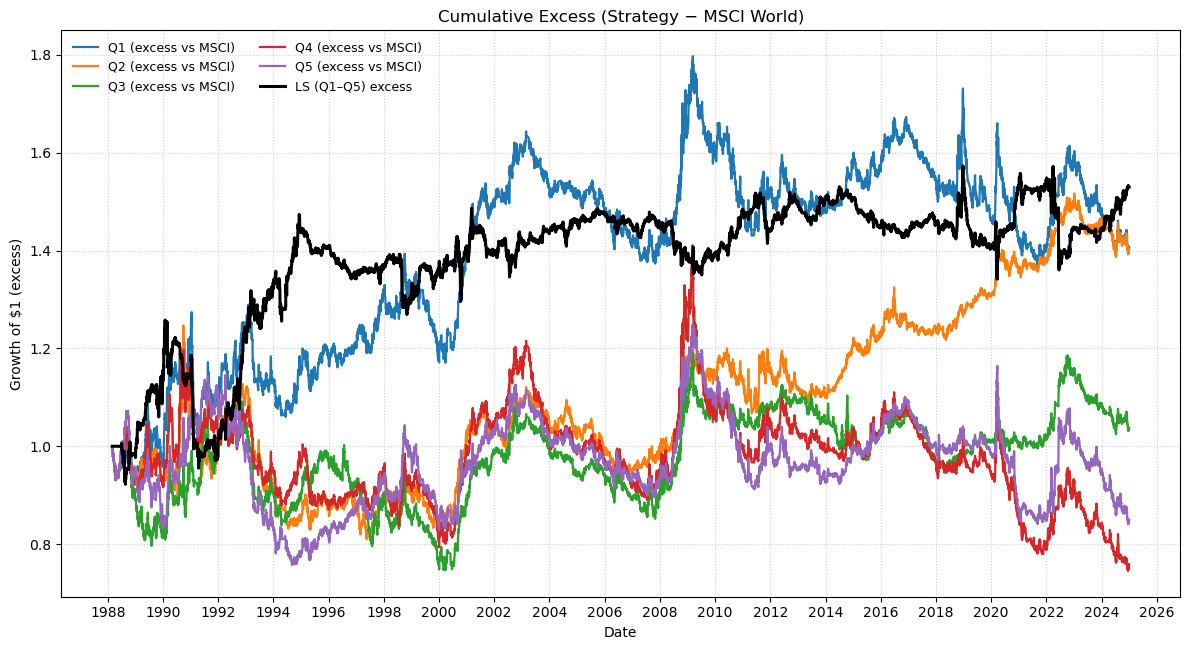

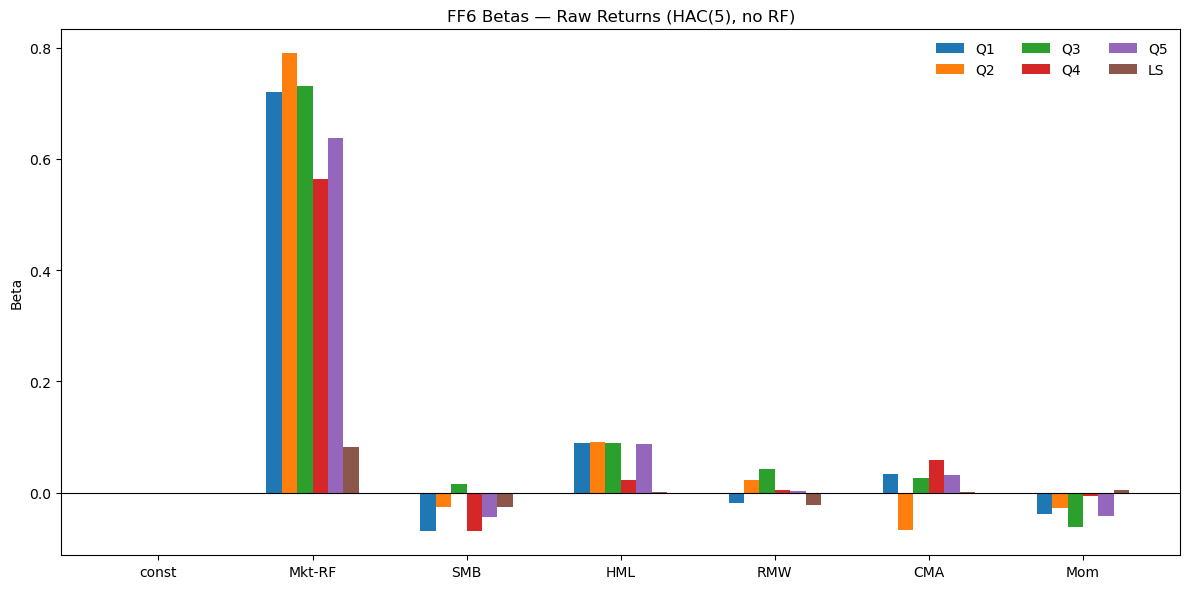

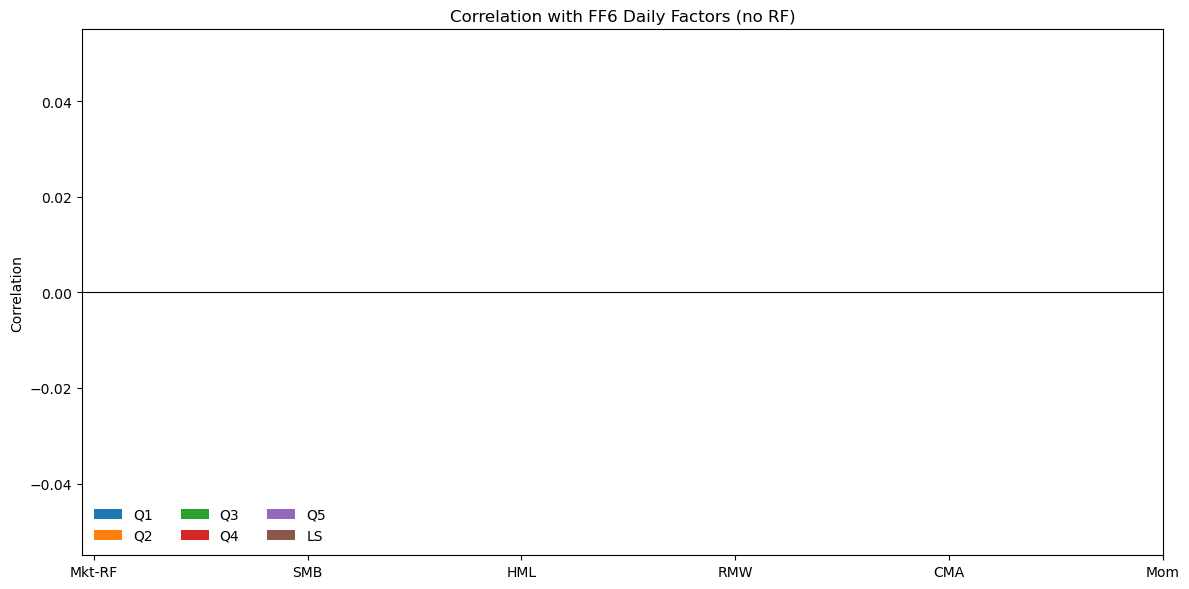


=== FF6 betas (no RF regressor) — daily raw returns ===


,const,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,0.0001,0.7211,-0.0686,0.0898,-0.0191,0.0328,-0.0377
Q2,0.0000,0.7900,-0.0252,0.0906,0.0235,-0.0669,-0.0278
Q3,0.0000,0.7316,0.0148,0.0892,0.0429,0.0261,-0.0613
Q4,0.0000,0.5639,-0.0696,0.0228,0.0040,0.0581,-0.0057
Q5,0.0001,0.6385,-0.0436,0.0883,0.0029,0.0315,-0.0422
LS,0.0000,0.0826,-0.0250,0.0015,-0.0220,0.0013,0.0046



=== FF6 t-stats (no RF regressor) ===


,const,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,2.67,90.90,-11.13,12.21,-1.67,3.31,-9.20
Q2,1.05,91.81,-2.86,10.13,2.10,-5.23,-4.93
Q3,1.53,53.36,1.41,8.28,3.07,2.06,-8.56
Q4,1.90,74.52,-8.31,2.03,0.31,4.67,-0.96
Q5,1.56,42.43,-4.11,6.38,0.16,1.88,-4.96
LS,0.33,7.05,-2.25,0.12,-1.26,0.08,0.53


In [8]:
# ============================================================
# Parquet + FF6 (no RF in regressors) + MSCI Excess Plot
# - Regressions & correlations on RAW returns (no RF regressor)
# - Keep cumulative plot of EXCESS vs MSCI for comparison
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from pathlib import Path

# ---------- PATHS ----------
PARQUET_PATH = Path(r"C:\Users\kelvi\Downloads\returns_daily_wide.parquet")
FF6_XLSX     = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"
FF6_CSV      = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.csv"
MSCI_XLSX    = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Stocks\World.xlsx"  # first col = date, 2nd = price

# ---------- LOADERS ----------
def load_daily_wide_parquet(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("Parquet must have a 'date' column or a DatetimeIndex.")
        df = df.sort_index()
    # keep numerics, drop *_cum, ensure LS
    for c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    keep = [c for c in df.columns if not str(c).endswith("_cum")]
    df = df[keep]
    if "LS" not in df and {"Q1","Q5"}.issubset(df.columns):
        df["LS"] = df["Q1"] - df["Q5"]
    return df

def read_ff6_pandas(xlsx_path: str | None, csv_path: str | None) -> pd.DataFrame:
    if xlsx_path and Path(xlsx_path).exists():
        ff = pd.read_excel(xlsx_path)
    elif csv_path and Path(csv_path).exists():
        ff = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("Provide a valid FF6 Excel or CSV path.")
    ren = {"Mkt_RF":"Mkt-RF", "MKTRF":"Mkt-RF", "RmMinusRf":"Mkt-RF", "rf":"RF", "UMD":"Mom", "WML":"Mom"}
    ff = ff.rename(columns={k:v for k,v in ren.items() if k in ff.columns})
    date_col = next(c for c in ff.columns if str(c).strip().lower() in {"date","dates"})
    ff["date"] = pd.to_datetime(ff[date_col], errors="coerce")
    ff = ff.dropna(subset=["date"]).drop(columns=[date_col]).sort_values("date")
    num_cols = [c for c in ff.columns if c != "date"]
    for c in num_cols: ff[c] = pd.to_numeric(ff[c], errors="coerce")
    ff[num_cols] = ff[num_cols] / 100.0  # %→decimals
    return ff.set_index("date")

def load_msci_world_daily_returns(xlsx_path: str) -> pd.Series:
    df = pd.read_excel(xlsx_path)
    date_col, px_col = df.columns[:2]
    df = df[[date_col, px_col]].rename(columns={date_col:"date", px_col:"px"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
    df["px"] = pd.to_numeric(df["px"], errors="coerce")
    df = df.dropna(subset=["px"])
    ret = df["px"].pct_change().fillna(0.0)
    ret.name = "MXWO_ret"
    return ret

# ---------- STATS ----------
def annualized_sharpe(x: pd.Series, periods=252) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x)==0: return np.nan
    s = x.std()
    return float((x.mean()/s)*np.sqrt(periods)) if s and s>0 else np.nan

def ann_ret(x: pd.Series, periods=252) -> float:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    n = x.shape[0]
    return float((1 + x).prod()**(periods/max(n,1)) - 1) if n else np.nan

def ann_vol(x: pd.Series, periods=252) -> float:
    x = pd.to_numeric(x, errors="coerce")
    return float(x.std()*np.sqrt(periods))

def run_ff6_regression_noRF(y: pd.Series, factors: pd.DataFrame, hac_lags: int = 5):
    """OLS(y ~ const + Mkt-RF + SMB + HML + RMW + CMA + Mom), HAC(5), no RF regressor."""
    pred = [c for c in ["Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in factors.columns]
    data = pd.concat([y.rename("y"), factors[pred]], axis=1).dropna()
    if data.empty: return None
    X = sm.add_constant(data[pred])
    m = sm.OLS(data["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return {
        "alpha_daily": m.params.get("const", np.nan),
        "alpha_ann": (1 + m.params.get("const", 0.0))**252 - 1 if pd.notna(m.params.get("const", np.nan)) else np.nan,
        "alpha_t": m.tvalues.get("const", np.nan),
        "R2": m.rsquared,
        "params": m.params, "tvals": m.tvalues, "predictors": pred
    }

def cumcurve(s: pd.Series) -> pd.Series:
    return (1.0 + pd.to_numeric(s, errors="coerce").fillna(0.0)).cumprod()

# ---------- LOAD ----------
dw   = load_daily_wide_parquet(PARQUET_PATH)
ff6  = read_ff6_pandas(FF6_XLSX, FF6_CSV)
mxwo = load_msci_world_daily_returns(MSCI_XLSX)

port_cols = [c for c in ["Q1","Q2","Q3","Q4","Q5","LS"] if c in dw.columns]

# Align for regression/correlation (intersection with FF6)
pred_cols = [c for c in ["Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in ff6.columns]
fac_on_dw = ff6[pred_cols].reindex(dw.index)
reg_idx   = dw.index.intersection(fac_on_dw.dropna().index)
dw_reg    = dw.loc[reg_idx, port_cols]
fac_reg   = fac_on_dw.loc[reg_idx]

# MSCI excess (plot only)
mxwo_on_dw = mxwo.reindex(dw.index).fillna(0.0)
excess = pd.DataFrame({c: dw[c] - mxwo_on_dw for c in port_cols if c != "LS"}, index=dw.index)
if {"Q1","Q5"}.issubset(dw.columns):
    excess["LS"] = excess["Q1"] - excess["Q5"]  # == Q1 - Q5

# ---------- Regressions (no RF) + Correlations ----------
results, corr_df = {}, pd.DataFrame(index=port_cols, columns=pred_cols, dtype=float)
for name in port_cols:
    res = run_ff6_regression_noRF(dw_reg[name], fac_reg, hac_lags=5)
    if res is not None: results[name] = res
    for f in pred_cols:
        corr_df.loc[name, f] = np.corrcoef(dw_reg[name], fac_reg[f])[0,1]

betas = pd.DataFrame({k: v["params"].reindex(["const"] + pred_cols) for k,v in results.items()}).T
tvals = pd.DataFrame({k: v["tvals"].reindex(["const"] + pred_cols)  for k,v in results.items()}).T

# ---------- PLOTS ----------
# (1) Cumulative EXCESS vs MSCI
plt.figure(figsize=(12, 6.6))
palette = {"Q1":"tab:blue","Q2":"tab:orange","Q3":"tab:green","Q4":"tab:red","Q5":"tab:purple","LS":"black","LO":"gray"}
for c in ["Q1","Q2","Q3","Q4","Q5"]:
    if c in excess.columns:
        plt.plot(cumcurve(excess[c]), label=f"{c} (excess vs MSCI)", color=palette[c], linewidth=1.6)
if "LS" in excess.columns:
    plt.plot(cumcurve(excess["LS"]), label="LS (Q1–Q5) excess", color="black", linewidth=2.2)
if "LO" in excess.columns:
    plt.plot(cumcurve(excess["LO"]), label="Long-only excess", color="gray", ls="--", linewidth=1.8)

plt.title("Cumulative Excess (Strategy − MSCI World)")
plt.xlabel("Date"); plt.ylabel("Growth of $1 (excess)")
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.legend(frameon=False, fontsize=9, ncols=2)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

# (2) FF6 Betas (NO RF regressor)
fac_for_plot = ["const"] + pred_cols
x = np.arange(len(fac_for_plot)); width = 0.10 if len(port_cols) >= 6 else 0.12
plt.figure(figsize=(max(12, 1.6*len(fac_for_plot)), 6.0))
for i, name in enumerate(port_cols):
    vals = betas.loc[name, fac_for_plot].values.astype(float)
    plt.bar(x + (i - len(port_cols)/2)*width + width/2, vals, width=width, label=name)
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, fac_for_plot); plt.title("FF6 Betas — Raw Returns (HAC(5), no RF)"); plt.ylabel("Beta")
plt.legend(frameon=False, ncols=3); plt.tight_layout(); plt.show()

# (3) Correlations with FF6 factors
x = np.arange(len(pred_cols)); width = 0.10 if len(port_cols) >= 6 else 0.12
plt.figure(figsize=(max(12, 1.6*len(pred_cols)), 6.0))
for i, name in enumerate(port_cols):
    vals = corr_df.loc[name, pred_cols].values.astype(float)
    plt.bar(x + (i - len(port_cols)/2)*width + width/2, vals, width=width, label=name)
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, pred_cols); plt.title("Correlation with FF6 Daily Factors (no RF)"); plt.ylabel("Correlation")
plt.legend(frameon=False, ncols=3); plt.tight_layout(); plt.show()

# ---------- TABLES ----------
print("\n=== FF6 betas (no RF regressor) — daily raw returns ==="); display(betas.round(4))
print("\n=== FF6 t-stats (no RF regressor) ==="); display(tvals.round(2))


In [9]:
# ---------- FF6 (no RF regressor) one-liner report ----------
def ff6_report(dw: pd.DataFrame, ff6: pd.DataFrame, targets: list[str], hac_lags: int = 5):
    """
    Runs OLS(y ~ const + Mkt-RF + SMB + HML + RMW + CMA + Mom) with HAC(maxlags=hac_lags)
    on each target in `targets`. Returns (coefs_df, tstats_df, meta_df).
    """
    # choose available factors
    all_pred = ["Mkt-RF","SMB","HML","RMW","CMA","Mom"]
    pred = [c for c in all_pred if c in ff6.columns]
    if not pred:
        raise ValueError("No FF6 predictors found in provided factor DataFrame.")

    # align on intersection where factors are non-null
    fac_on_dw = ff6[pred].reindex(dw.index)
    reg_idx = dw.index.intersection(fac_on_dw.dropna().index)

    coefs = {}
    tvals = {}
    meta  = []  # (name, alpha_daily, alpha_ann, alpha_t, R2, N)

    for name in targets:
        if name not in dw.columns:
            continue
        y = pd.to_numeric(dw.loc[reg_idx, name], errors="coerce")
        Xf = fac_on_dw.loc[reg_idx, pred]
        df_reg = pd.concat([y.rename("y"), Xf], axis=1).dropna()
        if df_reg.empty:
            continue

        X = sm.add_constant(df_reg[pred])
        m = sm.OLS(df_reg["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

        # store
        idx = ["const"] + pred
        coefs[name] = m.params.reindex(idx)
        tvals[name] = m.tvalues.reindex(idx)

        alpha = m.params.get("const", np.nan)
        alpha_ann = (1 + alpha)**252 - 1 if pd.notna(alpha) else np.nan
        meta.append({
            "series": name,
            "alpha_daily": alpha,
            "alpha_ann": alpha_ann,
            "alpha_t": m.tvalues.get("const", np.nan),
            "R2": m.rsquared,
            "N": int(m.nobs)
        })

    # DataFrames formatted nicely
    coefs_df = pd.DataFrame(coefs).T.round(6)
    tstats_df = pd.DataFrame(tvals).T.round(2)
    meta_df = pd.DataFrame(meta).set_index("series")
    return coefs_df, tstats_df, meta_df

# === RUN IT ===
targets = [c for c in ["Q1","Q2","Q3","Q4","Q5","LS","LO"] if c in dw.columns]  # adjust as you like
coefs_df, tstats_df, meta_df = ff6_report(dw, ff6, targets, hac_lags=5)

print("\n=== FF6 coefficients (daily units) — HAC(5), no RF regressor ===")
display(coefs_df)

print("\n=== FF6 t-stats — HAC(5), no RF regressor ===")
display(tstats_df)

print("\n=== Alpha & Fit Summary ===")
display(meta_df[["alpha_daily","alpha_ann","alpha_t","R2","N"]].round({
    "alpha_daily": 6, "alpha_ann": 4, "alpha_t": 2, "R2": 4
}))



=== FF6 coefficients (daily units) — HAC(5), no RF regressor ===


,const,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,0.000063,0.721067,-0.068592,0.089784,-0.019120,0.032776,-0.037669
Q2,0.000031,0.790023,-0.025242,0.090600,0.023524,-0.066895,-0.027759
Q3,0.000049,0.731603,0.014822,0.089211,0.042934,0.026148,-0.061312
Q4,0.000043,0.563906,-0.069591,0.022780,0.003985,0.058085,-0.005693
Q5,0.000051,0.638506,-0.043603,0.088275,0.002885,0.031471,-0.042219
LS,0.000012,0.082561,-0.024989,0.001509,-0.022006,0.001305,0.004550
LO,0.000141,1.004959,-0.030188,0.081036,-0.070705,-0.049653,0.018581



=== FF6 t-stats — HAC(5), no RF regressor ===


,const,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,2.67,90.90,-11.13,12.21,-1.67,3.31,-9.20
Q2,1.05,91.81,-2.86,10.13,2.10,-5.23,-4.93
Q3,1.53,53.36,1.41,8.28,3.07,2.06,-8.56
Q4,1.90,74.52,-8.31,2.03,0.31,4.67,-0.96
Q5,1.56,42.43,-4.11,6.38,0.16,1.88,-4.96
LS,0.33,7.05,-2.25,0.12,-1.26,0.08,0.53
LO,7.47,185.91,-4.56,10.62,-5.40,-5.16,3.10



=== Alpha & Fit Summary ===


,alpha_daily,alpha_ann,alpha_t,R2,N
series,,,,,
Q1,0.000063,0.0159,2.67,0.9423,8213
Q2,0.000031,0.0077,1.05,0.9291,8213
Q3,0.000049,0.0124,1.53,0.9020,8213
Q4,0.000043,0.0108,1.90,0.9061,8213
Q5,0.000051,0.0129,1.56,0.8616,8213
LS,0.000012,0.0030,0.33,0.0873,8213
LO,0.000141,0.0361,7.47,0.9770,8213


In [45]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def ff6_exposures_table(dw: pd.DataFrame, ff6: pd.DataFrame, targets=("Q1","Q2","Q3","Q4","Q5","LS")):
    # Use the same factors you regressed on (NO RF in X per your preference)
    Xcols = [c for c in ["Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in ff6.columns]
    out_rows = {}

    for name in targets:
        y = pd.to_numeric(dw[name], errors="coerce")
        data = pd.concat([y.rename("y"), ff6[Xcols]], axis=1).dropna()
        if data.empty:
            continue

        X = sm.add_constant(data[Xcols])
        ols = sm.OLS(data["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags":5})

        # Raw (unitless) betas
        row = {f"beta_{c}": float(ols.params.get(c, np.nan)) for c in Xcols}
        row.update({f"t_{c}": float(ols.tvalues.get(c, np.nan)) for c in Xcols})

        # Alpha as daily → annualized (%); betas remain unitless
        alpha_daily = float(ols.params.get("const", np.nan))
        row["alpha_ann_%"] = ( (1.0 + alpha_daily)**252 - 1.0 ) * 100.0 if np.isfinite(alpha_daily) else np.nan
        row["alpha_t"]     = float(ols.tvalues.get("const", np.nan))
        row["R2"]          = float(ols.rsquared)

        out_rows[name] = row

    cols_order = (["alpha_ann_%","alpha_t","R2"] +
                  sum(([f"beta_{c}", f"t_{c}"] for c in Xcols), []))
    return pd.DataFrame(out_rows).T.reindex(columns=cols_order)

# Example usage (dw indexed by date; ff6 indexed by date; both daily, decimals):
table = ff6_exposures_table(dw, ff6)
print(table.round(3))



    alpha_ann_%  alpha_t     R2  beta_Mkt-RF  t_Mkt-RF  beta_SMB   t_SMB  \
Q1        1.591    2.674  0.942        0.721    90.896    -0.069 -11.131   
Q2        0.773    1.053  0.929        0.790    91.807    -0.025  -2.862   
Q3        1.242    1.531  0.902        0.732    53.364     0.015   1.407   
Q4        1.079    1.902  0.906        0.564    74.517    -0.070  -8.308   
Q5        1.288    1.557  0.862        0.639    42.430    -0.044  -4.107   
LS        0.299    0.325  0.087        0.083     7.046    -0.025  -2.251   

    beta_HML   t_HML  beta_RMW  t_RMW  beta_CMA  t_CMA  beta_Mom  t_Mom  
Q1     0.090  12.212    -0.019 -1.668     0.033  3.310    -0.038 -9.200  
Q2     0.091  10.125     0.024  2.097    -0.067 -5.226    -0.028 -4.935  
Q3     0.089   8.277     0.043  3.073     0.026  2.056    -0.061 -8.557  
Q4     0.023   2.027     0.004  0.309     0.058  4.672    -0.006 -0.957  
Q5     0.088   6.384     0.003  0.160     0.031  1.877    -0.042 -4.961  
LS     0.002   0.123   

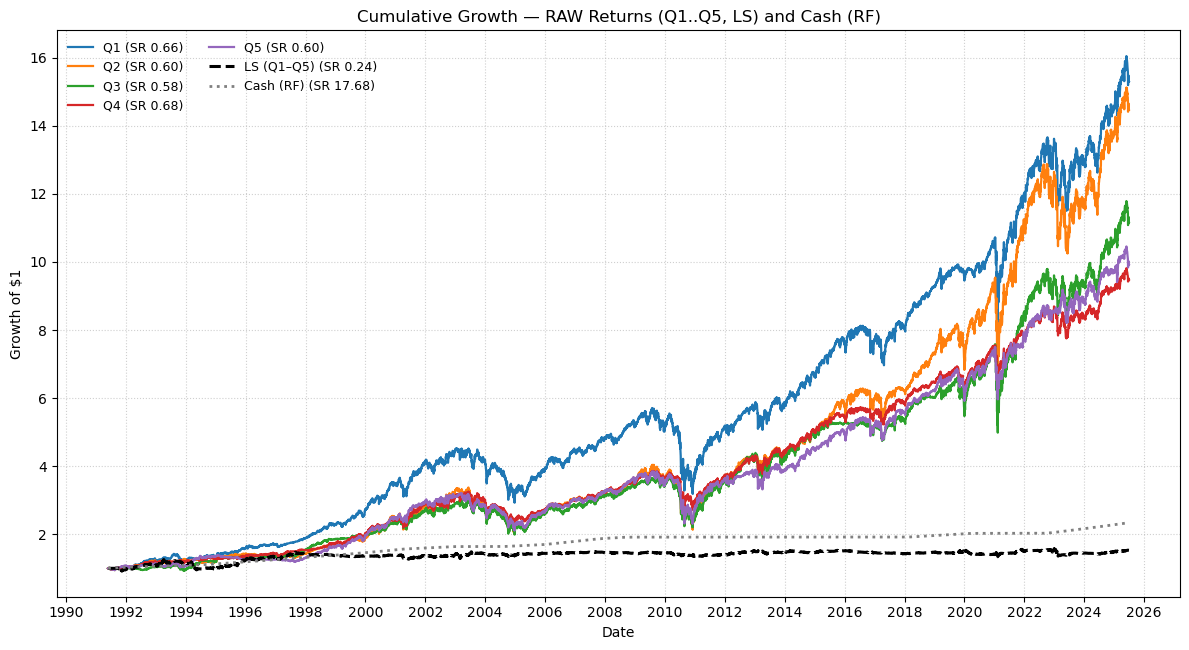


=== Summary (daily; RAW returns; Cash shown absolute) ===


,Ann. Ret,Ann. Vol,Ann. Sharpe
Q1,0.0803,0.1300,0.6598
Q2,0.0787,0.1434,0.6003
Q3,0.0707,0.1334,0.5795
Q4,0.0658,0.1019,0.6766
Q5,0.0672,0.1196,0.6035
LS (Q1–Q5),0.0121,0.0555,0.2448
Cash (RF),0.0244,0.0014,17.6848



=== FF6 Exposures (RAW returns) ===


,alpha (ann),alpha_t,R2,beta_Mkt-RF,t_Mkt-RF,beta_SMB,t_SMB,beta_HML,t_HML,beta_RMW,t_RMW,beta_CMA,t_CMA,beta_Mom,t_Mom
Q1,0.0910,4.2492,0.0006,-0.0022,-0.2737,-0.0352,-2.1099,0.0015,0.0799,-0.0119,-0.5839,-0.0026,-0.0914,-0.0089,-0.9104
Q2,0.0920,3.8882,0.0007,-0.0018,-0.1985,-0.0396,-2.0659,-0.0050,-0.2276,-0.0168,-0.6967,0.0004,0.0123,-0.0160,-1.3619
Q3,0.0811,3.7108,0.0007,-0.0045,-0.5413,-0.0395,-2.3483,0.0002,0.0082,-0.0093,-0.4724,0.0135,0.4552,-0.0056,-0.6278
Q4,0.0729,4.3739,0.0010,-0.0011,-0.1766,-0.0347,-2.6741,-0.0035,-0.2346,-0.0112,-0.6611,-0.0108,-0.4779,-0.0082,-1.0430
Q5,0.0754,3.8540,0.0004,-0.0012,-0.1547,-0.0270,-1.7491,-0.0055,-0.3213,0.0004,0.0203,-0.0009,-0.0348,-0.0046,-0.5166
LS (Q1–Q5),0.0145,1.5209,0.0005,-0.0010,-0.3165,-0.0082,-1.1447,0.0069,0.8742,-0.0123,-1.4003,-0.0017,-0.1489,-0.0043,-1.0269


In [1]:
# ============================================
# RAW returns: Plot + Summary + FF6 Exposures
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from pathlib import Path

# ---------- Paths (edit if needed) ----------
CACHE_DIR = Path(r"C:\Users\kelvi\Downloads")
DAILY_WIDE = CACHE_DIR / "returns_daily_wide.parquet"  
FF6_XLSX  = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"
FF6_CSV   = r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.csv"  

def load_daily_wide(path_parquet: Path) -> pd.DataFrame:
    csv = path_parquet.with_suffix(".csv")
    if path_parquet.exists():
        df = pd.read_parquet(path_parquet)
    elif csv.exists():
        df = pd.read_csv(csv, index_col=0)
    else:
        raise FileNotFoundError(f"Missing both {path_parquet} and {csv}")
    for c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def read_ff6_pandas(xlsx_path: str | None, csv_path: str | None) -> pd.DataFrame:
    if xlsx_path and Path(xlsx_path).exists():
        ff = pd.read_excel(xlsx_path)
    elif csv_path and Path(csv_path).exists():
        ff = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("Provide a valid path to FF6 Excel or CSV.")
    ren = {"Mkt_RF":"Mkt-RF", "MKTRF":"Mkt-RF", "RmMinusRf":"Mkt-RF", "rf":"RF", "UMD":"Mom", "WML":"Mom"}
    ff = ff.rename(columns={k:v for k,v in ren.items() if k in ff.columns})
    # date column
    date_col = next((c for c in ff.columns if str(c).strip().lower() in {"date","dates"}), None)
    if date_col is None:
        raise ValueError("Couldn't find a Date column in FF6 file.")
    ff["date"] = pd.to_datetime(ff[date_col], errors="coerce")
    ff = ff.dropna(subset=["date"]).drop(columns=[date_col]).sort_values("date")
    # numeric and convert % -> decimals
    num_cols = [c for c in ff.columns if c != "date"]
    for c in num_cols: ff[c] = pd.to_numeric(ff[c], errors="coerce")
    ff[num_cols] = ff[num_cols] / 100.0
    return ff.set_index("date")

def annualized_sharpe(x: pd.Series, periods_per_year=252) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0: return np.nan
    s = x.std()
    return float((x.mean()/s)*np.sqrt(periods_per_year)) if s and s>0 else np.nan

def ann_ret(x: pd.Series, periods=252) -> float:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    n = x.shape[0]
    return float((1 + x).prod()**(periods/max(n,1)) - 1) if n else np.nan

def ann_vol(x: pd.Series, periods=252) -> float:
    x = pd.to_numeric(x, errors="coerce")
    return float(x.std() * np.sqrt(periods))

def cumcurve(x: pd.Series) -> pd.Series:
    return (1.0 + pd.to_numeric(x, errors="coerce").fillna(0.0)).cumprod()

def assign_date_index_like(n: int, ref_series: pd.Series) -> pd.DatetimeIndex:
    """Use the last n dates from a DatetimeIndex reference (RF calendar)."""
    if not isinstance(ref_series.index, pd.DatetimeIndex) or len(ref_series) < n:
        raise ValueError("Reference series must be DatetimeIndex with length ≥ n.")
    return ref_series.index[-n:]

dw  = load_daily_wide(DAILY_WIDE)
ff6 = read_ff6_pandas(FF6_XLSX, FF6_CSV)

q_cols = [c for c in ["Q1","Q2","Q3","Q4","Q5"] if c in dw.columns]
if not q_cols: raise KeyError("Q1..Q5 not found in daily wide cache.")
if "LS" not in dw.columns:
    dw["LS"] = dw["Q1"] - dw["Q5"]
ls_col = "LS"

if "RF" not in ff6.columns:
    raise KeyError("RF not found in FF6 file.")
cash = ff6["RF"]

n = len(dw)
date_idx = assign_date_index_like(n, cash)
dw = dw.copy(); dw.index = date_idx; dw.index.name = "date"
cash_aligned = cash.reindex(dw.index).fillna(0.0)

series_raw = {q: pd.to_numeric(dw[q], errors="coerce") for q in q_cols}
ls_raw     = pd.to_numeric(dw[ls_col], errors="coerce")

sr = {q: annualized_sharpe(series_raw[q]) for q in q_cols}
sr_ls   = annualized_sharpe(ls_raw)
sr_cash = annualized_sharpe(cash_aligned)

plt.figure(figsize=(12, 6.6))
for q in q_cols:
    plt.plot(cumcurve(series_raw[q]), label=f"{q} (SR {sr[q]:.2f})", linewidth=1.6)
plt.plot(cumcurve(ls_raw), color="black", linewidth=2.2, linestyle="--",
         label=f"LS (Q1–Q5) (SR {sr_ls:.2f})")
plt.plot(cumcurve(cash_aligned), color="gray", linestyle=":", linewidth=2.0,
         label=f"Cash (RF) (SR {sr_cash:.2f})")

plt.title("Cumulative Growth — RAW Returns (Q1..Q5, LS) and Cash (RF)")
plt.xlabel("Date"); plt.ylabel("Growth of $1")
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.legend(frameon=False, fontsize=9, ncols=2)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

rows = {q: {"Ann. Ret": ann_ret(series_raw[q]),
            "Ann. Vol": ann_vol(series_raw[q]),
            "Ann. Sharpe": sr[q]} for q in q_cols}
rows["LS (Q1–Q5)"] = {"Ann. Ret": ann_ret(ls_raw),
                      "Ann. Vol": ann_vol(ls_raw),
                      "Ann. Sharpe": sr_ls}
rows["Cash (RF)"] = {"Ann. Ret": ann_ret(cash_aligned),
                     "Ann. Vol": ann_vol(cash_aligned),
                     "Ann. Sharpe": sr_cash}
summary_raw = pd.DataFrame(rows).T.reindex(q_cols + ["LS (Q1–Q5)","Cash (RF)"])
print("\n=== Summary (daily; RAW returns; Cash shown absolute) ===")
display(summary_raw.round(4))

factor_names = [c for c in ["Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in ff6.columns]
predictor_cols = factor_names
factors = ff6[predictor_cols].reindex(dw.index)

def run_ff6_regression_raw(series: pd.Series, factors: pd.DataFrame, hac_lags: int = 5):
    y = pd.to_numeric(series, errors="coerce")
    data = pd.concat([y.rename("y"), factors], axis=1).dropna()
    if data.empty: return None
    X = sm.add_constant(data[predictor_cols])
    model = sm.OLS(data["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    out = {
        "alpha_daily": model.params.get("const", np.nan),
        "alpha_ann": (1 + model.params.get("const", 0.0))**252 - 1 if pd.notna(model.params.get("const", np.nan)) else np.nan,
        "alpha_t": model.tvalues.get("const", np.nan),
        "R2": model.rsquared,
    }
    for f in predictor_cols:
        out[f"beta_{f}"] = model.params.get(f, np.nan)
        out[f"t_{f}"]    = model.tvalues.get(f, np.nan)
    return out

reg_targets = {q: series_raw[q] for q in q_cols}
reg_targets["LS (Q1–Q5)"] = ls_raw

results = {name: run_ff6_regression_raw(series, factors) for name, series in reg_targets.items()}

rows = {}
for name, res in results.items():
    if res is None: continue
    row = {"alpha (ann)": res["alpha_ann"], "alpha_t": res["alpha_t"], "R2": res["R2"]}
    for f in predictor_cols:
        row[f"beta_{f}"] = res.get(f"beta_{f}")
        row[f"t_{f}"]    = res.get(f"t_{f}")
    rows[name] = row

exposure_df_raw = pd.DataFrame(rows).T.reindex(q_cols + ["LS (Q1–Q5)"])
print("\n=== FF6 Exposures (RAW returns) ===")
display(exposure_df_raw.round(4))


In [19]:

import pandas as pd
import numpy as np

q_cols = [c for c in ["Q1","Q2","Q3","Q4","Q5"] if c in dw.columns]
if not q_cols:
    raise KeyError("Q1..Q5 not found in daily wide cache.")
if "LS" not in dw.columns:
    dw = dw.copy()
    dw["LS"] = dw["Q1"] - dw["Q5"]
port_cols = q_cols + ["LS"]

factor_cols = [c for c in ["RF","Mkt-RF","SMB","HML","RMW","CMA","Mom"] if c in ff6.columns]
if not factor_cols:
    raise KeyError("No FF6 factor columns found in ff6.")

factors = ff6[factor_cols].reindex(dw.index)

ports_df = dw[port_cols].apply(pd.to_numeric, errors="coerce")
data = pd.concat([ports_df, factors], axis=1).dropna(how="any")

pearson_corr = data[port_cols].corrwith(data[factor_cols], axis=0)  # this yields a Series; do pairwise matrix below
corr_pearson = data[port_cols].corrwith  # handy alias

corr_p = pd.DataFrame(
    {fac: data[port_cols].apply(lambda s: s.corr(data[fac])) for fac in factor_cols},
    index=port_cols
)

corr_s = pd.DataFrame(
    {fac: data[port_cols].apply(lambda s: s.corr(data[fac], method="spearman")) for fac in factor_cols},
    index=port_cols
)

print("=== Pearson correlation (RAW returns vs FF6) ===")
display(corr_p.round(3))

print("=== Spearman correlation (RAW returns vs FF6) ===")
display(corr_s.round(3))



=== Pearson correlation (RAW returns vs FF6) ===


,RF,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,0.012,-0.000,-0.021,-0.001,0.001,-0.001,-0.009
Q2,0.005,0.002,-0.021,-0.003,-0.001,-0.003,-0.014
Q3,0.004,-0.008,-0.024,0.005,0.007,0.009,-0.006
Q4,0.008,0.005,-0.027,-0.011,-0.002,-0.012,-0.009
Q5,0.008,-0.001,-0.020,-0.006,0.006,-0.003,-0.003
LS,0.010,0.000,-0.006,0.012,-0.010,0.004,-0.015


=== Spearman correlation (RAW returns vs FF6) ===


,RF,Mkt-RF,SMB,HML,RMW,CMA,Mom
Q1,0.001,-0.003,-0.019,-0.004,0.005,-0.001,-0.007
Q2,-0.013,-0.003,-0.019,-0.006,0.006,-0.004,-0.014
Q3,-0.012,-0.007,-0.024,0.000,0.009,0.007,-0.008
Q4,-0.004,-0.005,-0.024,-0.012,0.011,-0.006,-0.007
Q5,-0.009,-0.010,-0.015,-0.006,0.014,0.001,-0.009
LS,0.012,-0.007,-0.009,0.014,-0.001,0.005,-0.000
